# 02 — The Artifact-Interaction Divide

The central finding: **AI automates what you produce, not what you are.**

Tasks that produce artifacts (reports, code, data, transcripts) are automated at 2x
the rate of tasks that require human interaction (advising, counseling, teaching).
This holds regardless of education level, wage, or occupation — a PhD writing a
report and a clerk writing a memo are both automated. A PhD counseling a patient
and a clerk greeting a customer are both augmented.

The divide isn't about skill. It's about whether the output is a *document* or a *relationship*.

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.data import build_task_feature_matrix

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 150
C = {'auto': '#E63946', 'aug': '#457B9D', 'accent': '#F4A261', 'teal': '#2A9D8F'}

In [2]:
tasks = build_task_feature_matrix()
tu = tasks.drop_duplicates(subset='task_name').reset_index(drop=True)
reliable = tu[tu['conversation_count'] >= 20].copy()
reliable['first_verb'] = reliable['task_name'].str.lower().str.split().str[0]
print(f'Analyzing {len(reliable):,} tasks with >= 20 conversations')

Analyzing 2,819 tasks with >= 20 conversations


## Classifying tasks by output type

We categorize tasks by their *first verb* — the action that defines what the task produces.
This simple heuristic reveals a stark divide.

In [3]:
task_categories = {
    'Content production': ['write', 'prepare', 'draft', 'create', 'compile', 'compose', 'generate', 'produce'],
    'Data processing': ['calculate', 'compute', 'analyze', 'process', 'tabulate', 'convert', 'record', 'enter', 'transcribe'],
    'Planning & design': ['plan', 'design', 'develop', 'organize', 'coordinate', 'schedule', 'arrange'],
    'Information retrieval': ['read', 'research', 'gather', 'collect', 'review', 'search', 'find'],
    'Monitoring': ['monitor', 'supervise', 'oversee', 'track', 'check', 'verify', 'ensure', 'maintain'],
    'Evaluation': ['evaluate', 'assess', 'determine', 'select', 'recommend', 'judge'],
    'Physical / sensory': ['inspect', 'examine', 'observe', 'test', 'measure', 'operate', 'install', 'repair'],
    'Human interaction': ['advise', 'counsel', 'teach', 'explain', 'confer', 'consult', 'negotiate',
                          'interview', 'communicate', 'collaborate', 'educate', 'mentor', 'present'],
}

for cat, verbs in task_categories.items():
    reliable.loc[reliable['first_verb'].isin(verbs), 'task_type'] = cat

categorized = reliable.dropna(subset=['task_type']).copy()
print(f'{len(categorized):,} of {len(reliable):,} tasks categorized ({len(categorized)/len(reliable):.0%})')

1,633 of 2,819 tasks categorized (58%)


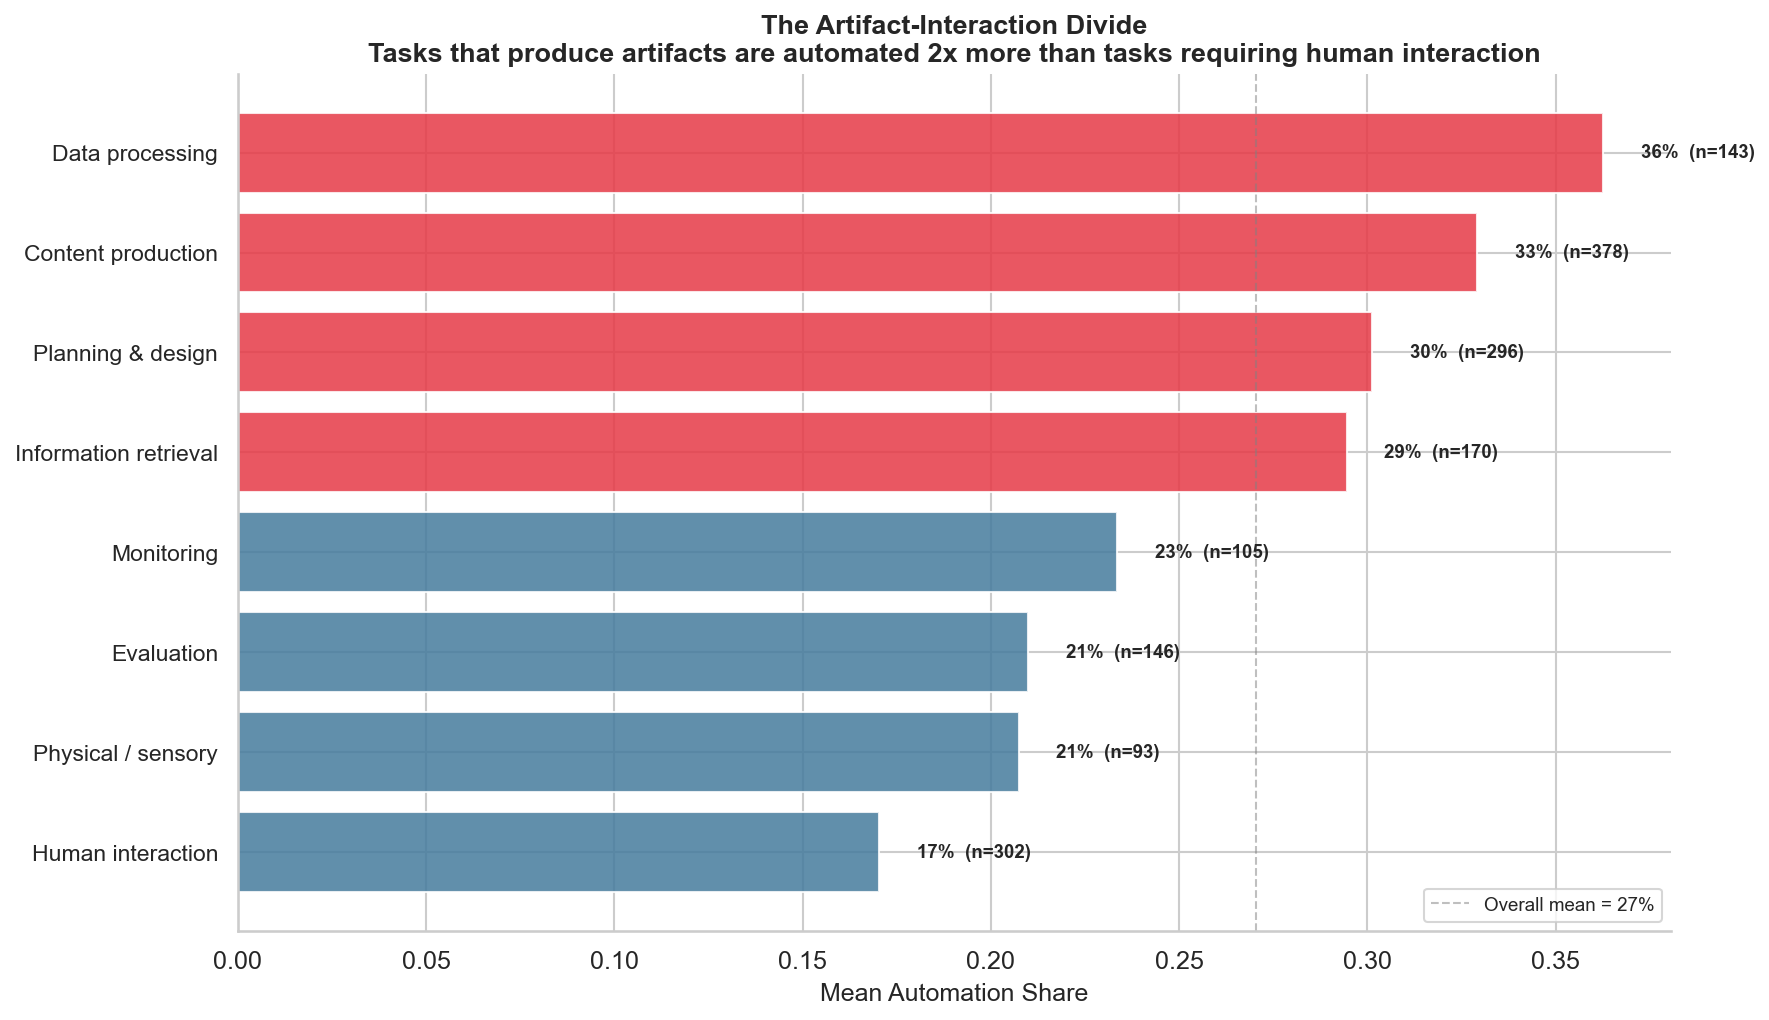

Content production: 33% automated
Human interaction:  17% automated
Gap: 16%


In [4]:
# The core result
cat_stats = (
    categorized.groupby('task_type')
    .agg(
        automation=('automation_share', 'mean'),
        autonomy=('ai_autonomy_mean', 'mean'),
        success=('success_rate', 'mean'),
        n=('task_name', 'count'),
    )
    .sort_values('automation', ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 7))
colors = [C['auto'] if v > 0.25 else C['aug'] for v in cat_stats['automation']]
bars = ax.barh(range(len(cat_stats)), cat_stats['automation'],
               color=colors, alpha=0.85, edgecolor='white')

for i, (cat, row) in enumerate(cat_stats.iterrows()):
    ax.text(row['automation'] + 0.01, i,
            f"{row['automation']:.0%}  (n={row['n']:.0f})",
            va='center', fontsize=9, fontweight='bold')

ax.set_yticks(range(len(cat_stats)))
ax.set_yticklabels(cat_stats.index, fontsize=11)
ax.set_xlabel('Mean Automation Share', fontsize=12)
ax.set_title('The Artifact-Interaction Divide\nTasks that produce artifacts are automated 2x more than tasks requiring human interaction',
             fontsize=13, fontweight='bold')
ax.axvline(categorized['automation_share'].mean(), color='gray', linestyle='--',
           linewidth=1, alpha=0.5, label=f"Overall mean = {categorized['automation_share'].mean():.0%}")
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig('../figures/04_artifact_interaction_divide.png', bbox_inches='tight')
plt.show()

print(f"Content production: {cat_stats.loc['Content production', 'automation']:.0%} automated")
print(f"Human interaction:  {cat_stats.loc['Human interaction', 'automation']:.0%} automated")
print(f"Gap: {cat_stats.loc['Content production', 'automation'] - cat_stats.loc['Human interaction', 'automation']:.0%}")

## Education doesn't matter — output type does

The most common narrative about AI automation is "low-skill jobs go first."
The data shows this is wrong. Education level barely predicts automation.
What matters is whether the task produces an *artifact* or requires *interaction*.

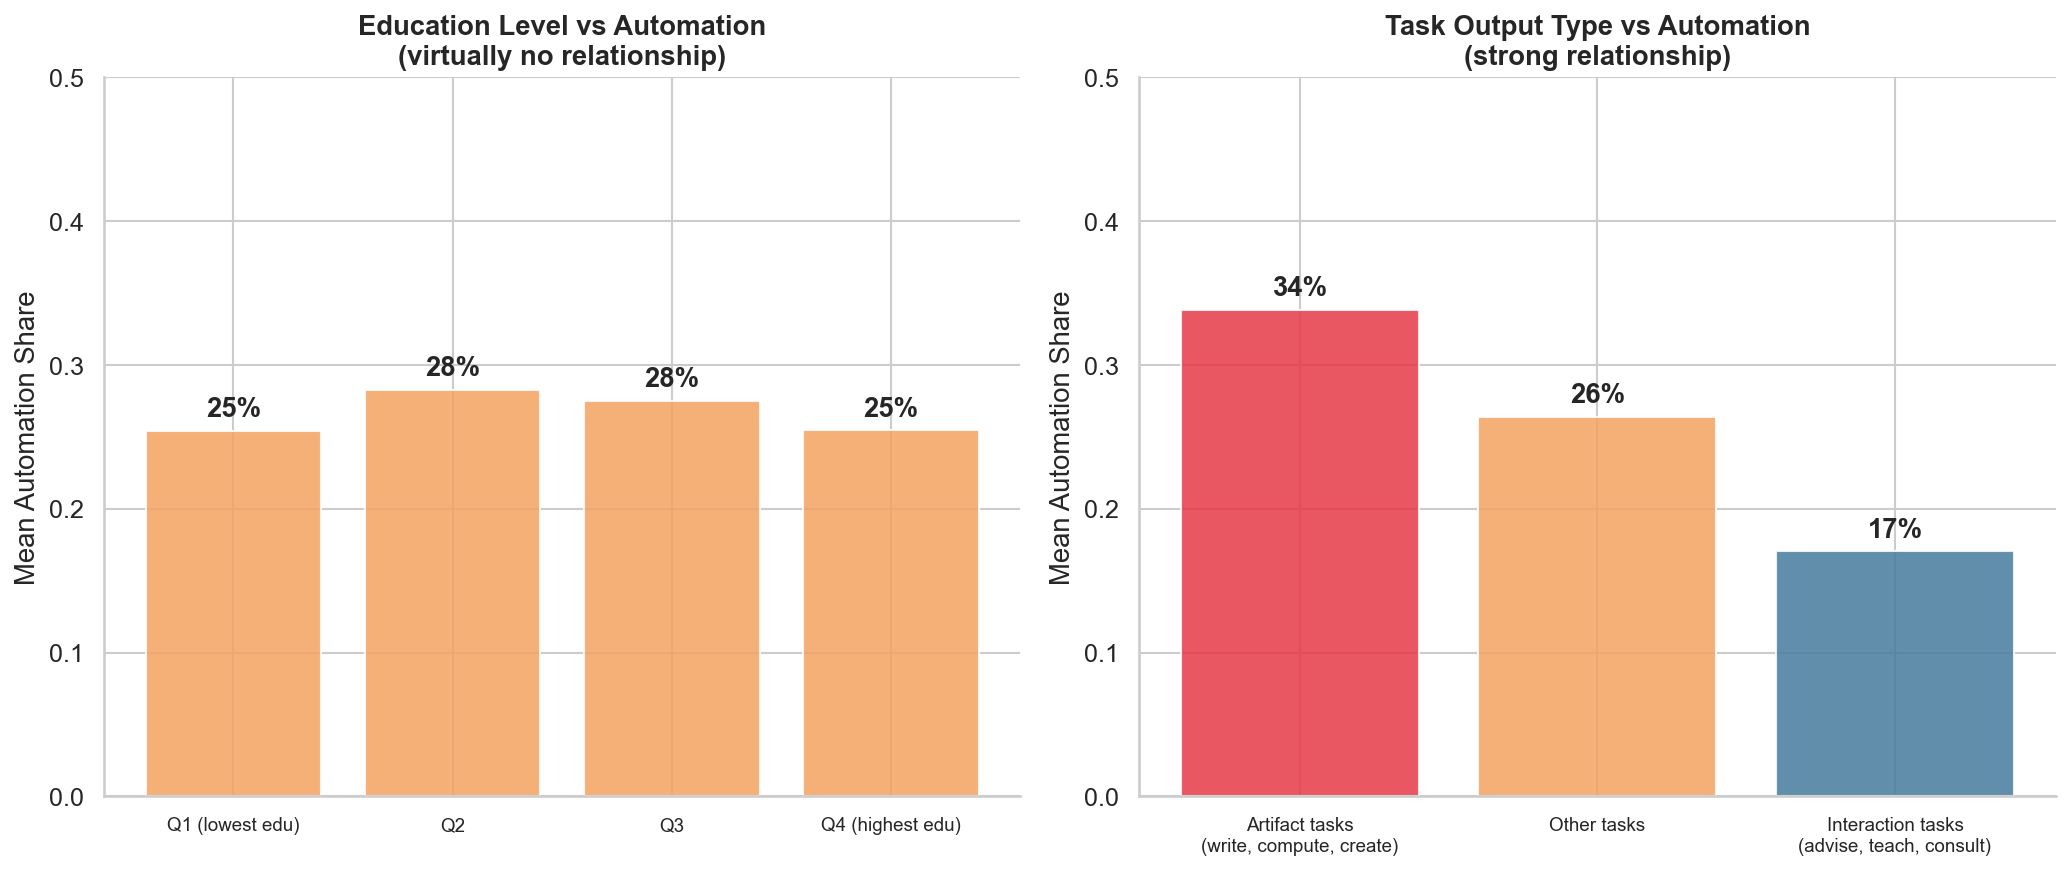

In [5]:
# Education quartiles vs automation
q = pd.qcut(reliable['human_education_years'], 4,
            labels=['Q1 (lowest edu)', 'Q2', 'Q3', 'Q4 (highest edu)'])
reliable['edu_quartile'] = q

edu_auto = reliable.groupby('edu_quartile')['automation_share'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: education vs automation (flat line)
ax = axes[0]
ax.bar(range(4), edu_auto.values, color=C['accent'], alpha=0.85, edgecolor='white')
ax.set_xticks(range(4))
ax.set_xticklabels(edu_auto.index, fontsize=9)
ax.set_ylabel('Mean Automation Share')
ax.set_title('Education Level vs Automation\n(virtually no relationship)', fontweight='bold')
ax.set_ylim(0, 0.5)
for i, v in enumerate(edu_auto.values):
    ax.text(i, v + 0.01, f'{v:.0%}', ha='center', fontweight='bold')

# Right: task type vs automation (strong relationship)
ax = axes[1]
artifact = categorized[categorized['task_type'].isin(['Content production', 'Data processing'])]
interact = categorized[categorized['task_type'] == 'Human interaction']
other = categorized[~categorized['task_type'].isin(['Content production', 'Data processing', 'Human interaction'])]

groups = ['Artifact tasks\n(write, compute, create)', 'Other tasks', 'Interaction tasks\n(advise, teach, consult)']
vals = [artifact['automation_share'].mean(), other['automation_share'].mean(), interact['automation_share'].mean()]
colors_bar = [C['auto'], C['accent'], C['aug']]
ax.bar(range(3), vals, color=colors_bar, alpha=0.85, edgecolor='white')
ax.set_xticks(range(3))
ax.set_xticklabels(groups, fontsize=9)
ax.set_ylabel('Mean Automation Share')
ax.set_title('Task Output Type vs Automation\n(strong relationship)', fontweight='bold')
ax.set_ylim(0, 0.5)
for i, v in enumerate(vals):
    ax.text(i, v + 0.01, f'{v:.0%}', ha='center', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.savefig('../figures/05_education_vs_output_type.png', bbox_inches='tight')
plt.show()

## Concrete examples: what gets automated vs. augmented

The most and least automated tasks make the pattern vivid.

In [6]:
print('MOST AUTOMATED TASKS (reliable data, >=50 conversations):')
print('=' * 85)
high_vol = reliable[reliable['conversation_count'] >= 50]
for _, r in high_vol.nlargest(10, 'automation_share').iterrows():
    print(f"  {r['automation_share']:.0%} automated | {r['task_name'][:75]}")

print()
print('LEAST AUTOMATED TASKS (purely augmentative):')
print('=' * 85)
for _, r in high_vol[high_vol['automation_share'] == 0].sample(10, random_state=42).iterrows():
    print(f"  {r['automation_share']:.0%} automated | {r['task_name'][:75]}")

MOST AUTOMATED TASKS (reliable data, >=50 conversations):
  96% automated | maintain knowledge of relevant national and international current events.
  95% automated | prepare and deliver news, sports, or weather reports, gathering and rewriti
  91% automated | report on specialized fields such as medicine, green technology, environmen
  89% automated | provide information about community health and social resources.
  89% automated | read trade journals and professional literature to stay informed on trends,
  86% automated | perform needs assessments or consult with clients to determine the types of
  86% automated | transcribe recorded proceedings in accordance with established formats.
  86% automated | take dictation using shorthand, a stenotype machine, or headsets and transc
  85% automated | create, analyze, report, convert, or transfer data, using specialized appli
  84% automated | conduct needs assessments and strategic learning assessments to develop the

LEAST AUTOMATED TA

## The automation-success paradox

Automated tasks have **lower** success rates than augmented tasks.
This isn't because automation is bad — it's because people use AI autonomously
for *harder, more ambitious* tasks where perfect success isn't the goal.

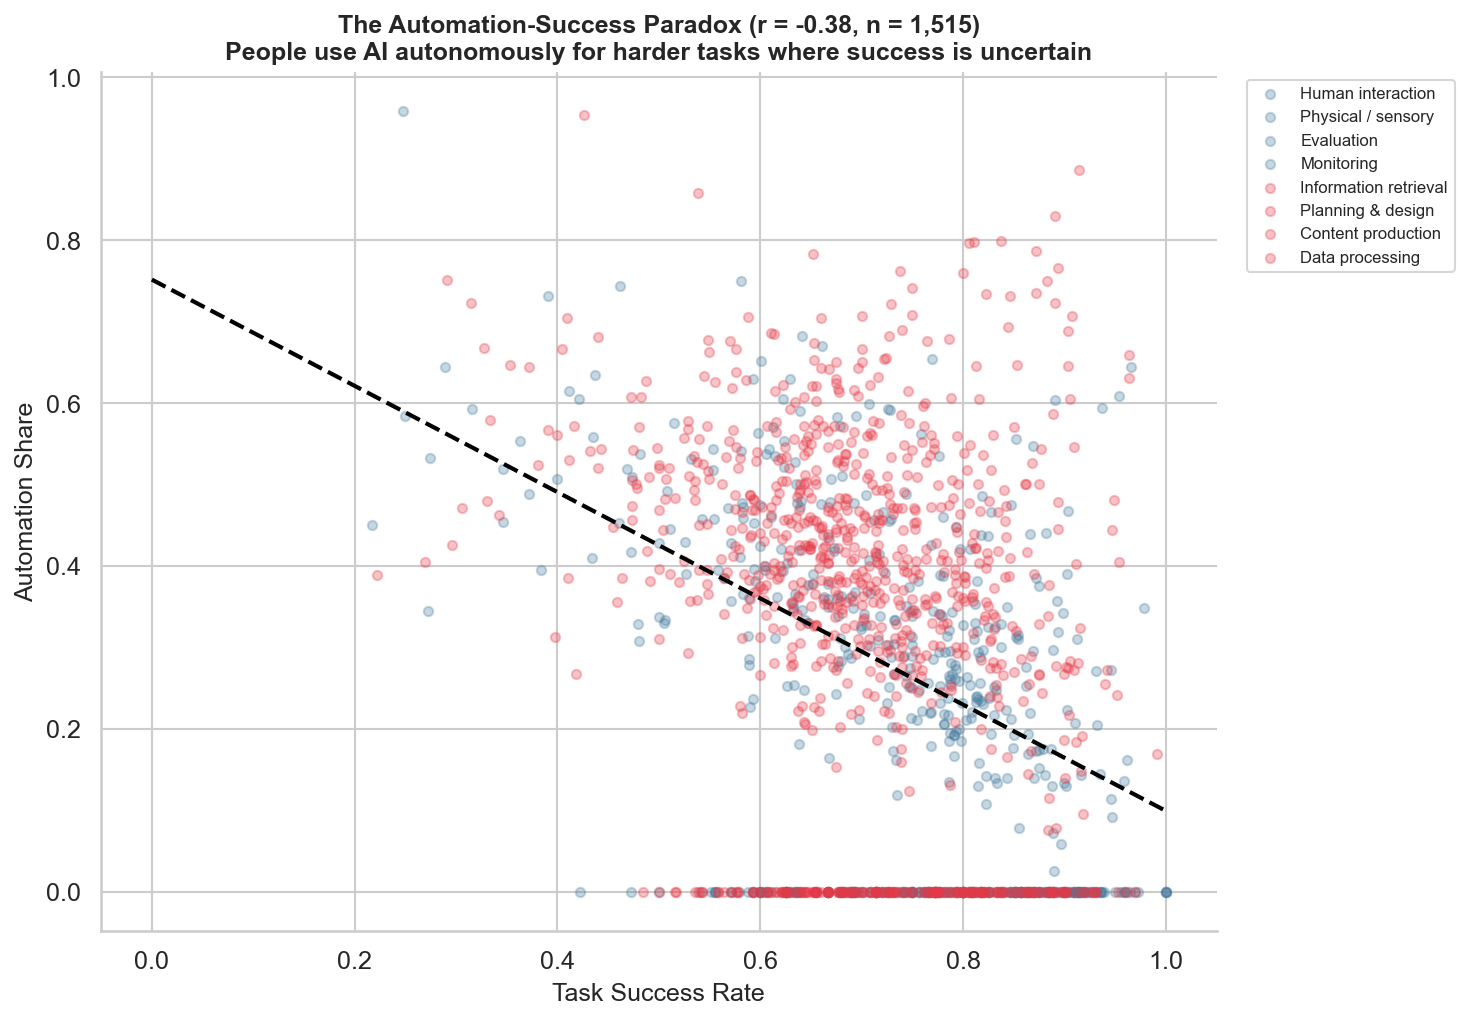

In [7]:
valid = categorized.dropna(subset=['success_rate']).copy()

fig, ax = plt.subplots(figsize=(10, 7))
for cat in cat_stats.index:
    subset = valid[valid['task_type'] == cat]
    color = C['auto'] if cat_stats.loc[cat, 'automation'] > 0.25 else C['aug']
    ax.scatter(subset['success_rate'], subset['automation_share'],
              alpha=0.3, s=20, color=color, label=cat)

r, p = stats.pearsonr(valid['success_rate'], valid['automation_share'])
z = np.polyfit(valid['success_rate'], valid['automation_share'], 1)
ax.plot([0, 1], [np.poly1d(z)(0), np.poly1d(z)(1)], '--', color='black', linewidth=2)

ax.set_xlabel('Task Success Rate', fontsize=12)
ax.set_ylabel('Automation Share', fontsize=12)
ax.set_title(f'The Automation-Success Paradox (r = {r:.2f}, n = {len(valid):,})\n'
             f'People use AI autonomously for harder tasks where success is uncertain',
             fontsize=12, fontweight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
sns.despine()
plt.tight_layout()
plt.savefig('../figures/06_automation_success_paradox.png', bbox_inches='tight')
plt.show()

## Skill compression: AI as equalizer

For each task, the AEI estimates how many years of education a human needs vs.
how many the AI needs. The gap — *skill compression* — is small on average
but reveals which tasks AI democratizes most.

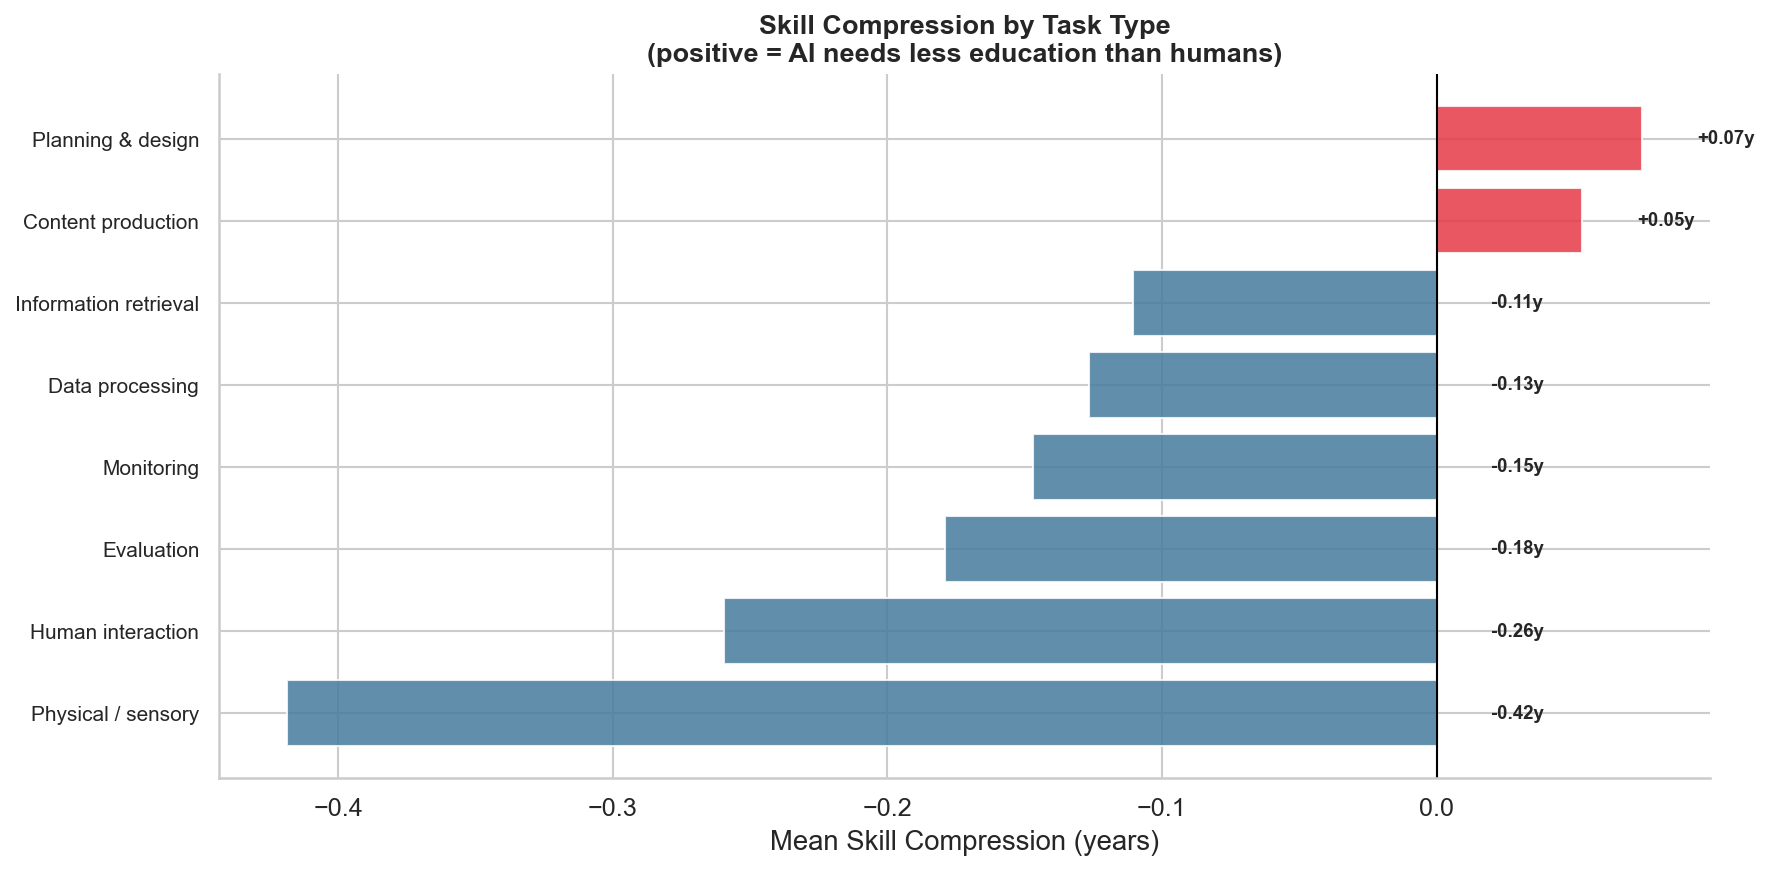

Planning & design tasks see the most skill compression — AI needs ~0.1 fewer years.
Physical/sensory tasks see the least — AI needs ~0.4 MORE years of equivalent training.
The effect is modest but systematic.


In [8]:
sc_by_type = categorized.groupby('task_type')['skill_compression'].agg(['mean', 'std', 'count'])
sc_by_type = sc_by_type.sort_values('mean')

fig, ax = plt.subplots(figsize=(12, 6))
colors_sc = [C['auto'] if v > 0 else C['aug'] for v in sc_by_type['mean']]
ax.barh(range(len(sc_by_type)), sc_by_type['mean'], color=colors_sc, alpha=0.85)
ax.axvline(0, color='black', linewidth=1)
ax.set_yticks(range(len(sc_by_type)))
ax.set_yticklabels(sc_by_type.index, fontsize=10)
ax.set_xlabel('Mean Skill Compression (years)')
ax.set_title('Skill Compression by Task Type\n(positive = AI needs less education than humans)',
             fontsize=13, fontweight='bold')

for i, (_, row) in enumerate(sc_by_type.iterrows()):
    ax.text(max(row['mean'], 0) + 0.02, i, f"{row['mean']:+.2f}y",
            va='center', fontsize=9, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.savefig('../figures/07_skill_compression_by_type.png', bbox_inches='tight')
plt.show()

print('Planning & design tasks see the most skill compression — AI needs ~0.1 fewer years.')  
print('Physical/sensory tasks see the least — AI needs ~0.4 MORE years of equivalent training.')
print('The effect is modest but systematic.')

---

**Key findings:**
1. **Output type, not skill level**, determines automation — artifact-producing tasks are 2x more automated than interaction tasks
2. **Education is irrelevant** — high-education and low-education tasks automate at the same rate
3. **The automation-success paradox** — automated tasks have lower success rates because people use AI autonomously for harder, more ambitious work
4. **Skill compression is modest but systematic** — AI reduces education barriers most for planning/design tasks

**Next:** [03_task_level_analysis.ipynb](03_task_level_analysis.ipynb)